# Artificial Intelligence in the Research Literature since 2000: OpenAlex Analysis with a DataCite DOI Check

DATASCI 530 — Assignment 3<br>
Author: *Rola*<br>
Data: OpenAlex Works API (`https://api.openalex.org/works`) and DataCite DOI API (`https://api.datacite.org/dois/`), retrieved 28 September 2026

## Summary of findings

- The title search found 330,744 works. About 89.5% were dated 2020–2026, but this includes the unfinished year 2026, which alone made up 27.5% of all matches (Tables 1 and 2).
- The United States led the country ranking with 36,515 works, followed by China with 29,722 and India with 24,672. Their shares of works with a known country were 18.0%, 14.6%, and 12.2%, respectively (Table 4).
- Eric J. Topol's paper in *Nature Medicine*, recorded as 2018 in the saved data, ranked first with 10,188 citations. All ten of the most-cited articles and reviews were dated 2017–2020 (Table 7).
- In 2025, the title searches returned 76,545 works for "artificial intelligence," 28,384 for "LLM," and 2,573 for "GPT." From 2024 to 2025, those counts changed by +57%, +161%, and −3%, respectively. "Machine learning" had the largest count, at 105,008 works (Table 12).
- The main field shift had already happened by 2016–2022: medicine's share rose from 6.5% to 28.8%, then stayed near that level at 28.6% in 2023–2025. All 26 fields had AI papers in every period, but the two largest fields' combined share fell from 60.5% to 50.0%, so the papers became less concentrated (Tables 15 and 16).

## Data and methodology

- I used the OpenAlex responses saved on September 28, 2026 for the publication analysis, and DataCite to check the DOI of a suspicious preprint. The request log identifies both APIs and their saved files (Tables 6 and A1).
- I searched titles for the phrase "artificial intelligence" so that the definition would be clear and repeatable. I compared it with a looser two-word search to see how much that choice affected the total (Table 1).
- I chose "machine learning" as the additional keyword because it is an established area of AI and gives a useful comparison with the newer "LLM" and "GPT" terms. It also helps show how results depend on the words authors put in their titles (Table 12).
- I let OpenAlex count the matches with `group_by` because I needed totals by year, country, type, and field, rather than downloading roughly 330,000 individual records. This reduced the amount of data and number of requests needed; the smaller record downloads were used for the citation ranking and checks (Tables 1 and A1).
- I saved each response as JSON to avoid spending more of the daily API allowance when rerunning the notebook and to keep a fixed snapshot while OpenAlex's records and citation counts change. Table A1 lists the saved requests; OpenAlex documents the daily limit in its [API authentication guide](https://help.openalex.org/api/authentication/).
- I used 2000–2026 for the country and citation rankings, then repeated the country ranking through 2025 to check the effect of the partial year. I stopped the trend and field comparisons at 2025 so that their final year was complete (Tables 4, 7, 12, and 15).
- I counted a paper once for every country represented in its author affiliations because the ranking measures each country's participation in research. This gives each collaborating country credit, but the shares overlap: works with a known country averaged 1.32 countries each (Table 4; Quality check 2).
- I counted all record types for the main totals and used articles and reviews for the top-ten paper list and the adjusted comparisons. For the yearly rates, both the numerator and denominator use articles and reviews. All OpenAlex records rose 34.7% in 2025 and 121.2% in 2026, while articles and reviews rose only 16.8% in 2025; using the same narrower types makes the comparison less sensitive to changes in the mix of records (Tables 3, 7, 11, and 14).
- Along with checking totals, missing data, and duplicate authors, I added two checks: comparing country ranks with and without 2026, and comparing the preprint's OpenAlex title with the title registered for its DOI in DataCite (Tables 4 and 6; Quality checks 1–5).

## Setup

In [1]:
import os                  # check whether a saved JSON file exists
import json                # read and write JSON files
import time                # retrieval date and a short pause between requests
import requests            # send requests to the APIs
import jmespath            # extract values from nested JSON (Lecture 5b)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
                     "legend.fontsize": 10, "figure.dpi": 110})

In [2]:
# ---- API settings -------------------------------------------------------------
url_openalex_works = "https://api.openalex.org/works"    # OpenAlex Works endpoint (one record = one work)
url_datacite       = "https://api.datacite.org/dois/"    # DataCite DOI registry (used once, in Question 3)
folder_cache       = "json_files/openalex/"              # folder where every API response is saved
refresh_cache      = False                               # False = reuse saved responses; True = download again
api_key            = os.environ.get("OPENALEX_API_KEY")  # optional free OpenAlex key; None if not set

os.makedirs(folder_cache, exist_ok = True)

# ---- Definition of an "AI publication" -----------------------------------------
# filter_ai: works whose TITLE contains the exact phrase "artificial intelligence".
# The double quotes make OpenAlex search for the phrase, not the two words anywhere.
filter_ai = 'title.search:"artificial intelligence"'

# ---- Readable labels for OpenAlex's "type" codes --------------------------------
dict_type_labels = {"article":          "Journal article",
                    "review":           "Review article",
                    "conference-paper": "Conference paper",
                    "book-chapter":     "Book chapter",
                    "book":             "Book",
                    "preprint":         "Preprint",
                    "paratext":         "Paratext (front matter)"}

# ---- One fixed color and line style per search term (same in every figure) ------
dict_colors = {"artificial intelligence": "#2a78d6",
               "LLM":                     "#eb6834",
               "GPT":                     "#1baf7a",
               "machine learning":        "#eda100"}
dict_styles = {"artificial intelligence": "-",
               "LLM":                     "--",
               "GPT":                     ":",
               "machine learning":        "-."}

# ---- list_requests: log of every API request (shown in the appendix) -------------
list_requests = []

### Helper functions

- These functions download responses and save a copy so the notebook can reuse the same data; the request log shows the saved files (Table A1).
- The country search collects extra pages when the groups do not fit on one page, so the top-20 ranking is based on all available country groups (Tables 4 and A1).
- The table function applies consistent captions, number formats, and alignment to the results (Tables 1–16).

In [3]:
def get_json(url, parameters, file_name):
    # Returns the JSON response of `url` with query `parameters` as a dictionary.
    # The response is saved to json_files/openalex/<file_name>.json together with the
    # request, and reused on later runs as long as the request is exactly the same.

    file_path = folder_cache + file_name + ".json"
    list_requests.append({"url": url, "file": file_name + ".json", "parameters": parameters})

    # 1. Reuse the saved response if it came from exactly the same request
    if os.path.exists(file_path) and (refresh_cache == False):
        with open(file_path, "r", encoding = "utf-8") as file:
            saved = json.load(file)
        if saved["parameters"] == parameters:
            return saved["response"]

    # 2. Otherwise call the API. The OpenAlex key is added to the request only, never saved.
    request_parameters = parameters.copy()
    if (url == url_openalex_works) and (api_key is not None):
        request_parameters["api_key"] = api_key

    response = requests.get(url, params = request_parameters, timeout = 60)
    if response.status_code == 429:
        raise RuntimeError("Rate limit reached for " + url + ": wait for the daily reset "
                           "(OpenAlex: or set OPENALEX_API_KEY).")
    response.raise_for_status()
    data = response.json()

    with open(file_path, "w", encoding = "utf-8") as file:
        json.dump({"parameters": parameters,
                   "retrieved":  time.strftime("%Y-%m-%d"),
                   "response":   data},
                  file, indent = 4, ensure_ascii = False)
    time.sleep(0.2)
    return data


def get_openalex(parameters, file_name):
    # Same as get_json(), for the OpenAlex Works endpoint
    return get_json(url_openalex_works, parameters, file_name)


def get_groups(parameters, file_name):
    # Runs a group_by request: OpenAlex counts the matching works per group (year, country, ...).
    # Returns (table with one row per group: key, key_display_name, count ; total matching works)
    data   = get_openalex(parameters, file_name)
    groups = pd.DataFrame(data["group_by"], columns = ["key", "key_display_name", "count"])
    return groups, data["meta"]["count"]


def get_all_groups(parameters, file_name):
    # Same as get_groups(), but for more than 200 groups: OpenAlex returns at most 200
    # groups per page plus a "next_cursor", so the loop keeps requesting pages until a
    # page is not full.
    list_groups = []
    cursor      = "*"                     # "*" = first page
    page        = 1

    while cursor is not None:
        page_parameters = parameters.copy()
        page_parameters["per_page"] = 200
        page_parameters["cursor"]   = cursor

        data        = get_openalex(page_parameters, file_name + "_page" + str(page))
        list_groups = list_groups + data["group_by"]
        cursor      = data["meta"]["next_cursor"]

        if len(data["group_by"]) < 200:   # a page that is not full is the last one
            cursor = None
        page = page + 1

    groups = pd.DataFrame(list_groups, columns = ["key", "key_display_name", "count"])
    return groups, data["meta"]["count"]


def shorten(text, max_characters):
    # Cuts long text for display and marks the cut with "…"
    if len(text) <= max_characters:
        return text
    return text[0:max_characters - 1] + "…"


def style_table(table, caption, formats, nowrap_columns = []):
    # Same table style everywhere: formatted numbers, no index, caption above, text left-aligned.
    # nowrap_columns: short columns that should stay on one line
    table  = table.reset_index(drop = True)       # unique row numbers (tables built with pd.concat repeat them)
    styled = (table.style.format(formats, na_rep = "")
                         .hide(axis = "index")
                         .set_caption(caption)
                         .set_table_styles([{"selector": "caption",
                                             "props": "caption-side: top; text-align: left; font-weight: bold;"},
                                            {"selector": "th, td", "props": "text-align: left; vertical-align: top;"}]))
    if len(nowrap_columns) > 0:
        styled = styled.set_properties(subset = nowrap_columns, **{"white-space": "nowrap"})
    return styled

## Question 1: How many works have "artificial intelligence" in their titles?

- I first counted works with the phrase "artificial intelligence" in the title, across all years and types of work (Table 1).
- I also searched for the two words without requiring the phrase, then compared the totals (Table 1).
- I grouped the phrase matches by year and type to see what the search included (Tables 2 and 3).

In [4]:
# q1_phrase, q1_words: raw API responses. per_page = 1 because only meta["count"]
# (the number of matching works) is needed, not the records themselves.
q1_phrase = get_openalex({"filter": filter_ai, "per_page": 1, "select": "id"},
                         "q1_title_phrase")
q1_words  = get_openalex({"filter": "title.search:artificial intelligence", "per_page": 1, "select": "id"},
                         "q1_title_words")

n_ai_titles = q1_phrase["meta"]["count"]     # works with the exact phrase in the title (main definition)
n_ai_words  = q1_words["meta"]["count"]      # works with both words anywhere in the title

# q1_years: one row per publication year, with the number of matching works (all years, all types)
# q1_types: one row per type of work (article, book, ...), with the number of matching works
q1_years, _ = get_groups({"filter": filter_ai, "group_by": "publication_year:include_unknown"}, "q1_by_year")
q1_types, _ = get_groups({"filter": filter_ai, "group_by": "type"}, "q1_by_type")

# OpenAlex returns works with no publication year under the year key -111
q1_years["year"] = q1_years["key"].astype(int)
n_no_year = q1_years.query("year == -111")["count"].sum()
q1_years  = q1_years.query("year != -111").copy()

In [5]:
# Table 1: the phrase search vs. the looser two-word search
table_search = pd.DataFrame({
    "Search": ['Exact phrase "artificial intelligence" in the title (definition used)',
               'Both words "artificial" and "intelligence" anywhere in the title'],
    "Works":  [n_ai_titles, n_ai_words],
    "Difference from the exact phrase": ["", f"{(n_ai_words / n_ai_titles - 1) * 100:+.1f}%"]
})
display(style_table(table_search, 'Table 1. Works with "artificial intelligence" in the title '
                                  '(all years, all types of work)',
                    {"Works": "{:,.0f}"}))

# Table 2: the same works split into publication periods (the rows add up to the total)
table_periods = pd.DataFrame({
    "Publication year": ["Before 2000", "2000–2019", "2020–2025", "2026 (partial year)",
                         "After 2026 (date errors)", "No publication year"],
    "Works":            [q1_years.query("year < 2000")["count"].sum(),
                         q1_years.query("(year >= 2000) & (year <= 2019)")["count"].sum(),
                         q1_years.query("(year >= 2020) & (year <= 2025)")["count"].sum(),
                         q1_years.query("year == 2026")["count"].sum(),
                         q1_years.query("year > 2026")["count"].sum(),
                         n_no_year]
})
share = table_periods["Works"] / n_ai_titles * 100
table_periods["Share of all works"] = [f"{x:.1f}%" if x >= 0.05 else "<0.1%" for x in share]

# Combined periods used in the text (they overlap the rows above, so they go in the caption)
n_2000_2026 = q1_years.query("(year >= 2000) & (year <= 2026)")["count"].sum()
n_2020_2026 = q1_years.query("(year >= 2020) & (year <= 2026)")["count"].sum()

display(style_table(table_periods, 'Table 2. Works with the phrase in the title by publication period '
                           '(data retrieved 28 September 2026). Combined: 2000–2026 = '
                           f'{n_2000_2026:,} ({n_2000_2026 / n_ai_titles * 100:.1f}%); 2020–2026 = '
                           f'{n_2020_2026:,} ({n_2020_2026 / n_ai_titles * 100:.1f}%).',
            {"Works": "{:,.0f}"}))

Search,Works,Difference from the exact phrase
"Exact phrase ""artificial intelligence"" in the title (definition used)","330,744",
"Both words ""artificial"" and ""intelligence"" anywhere in the title","333,698",+0.9%


Publication year,Works,Share of all works
Before 2000,"7,582",2.3%
2000–2019,"25,815",7.8%
2020–2025,"205,199",62.0%
2026 (partial year),"90,830",27.5%
After 2026 (date errors),7,<0.1%
No publication year,"1,311",0.4%


In [6]:
# Table 3: type of work (six most common types + one row for all the others)
q1_types = q1_types.sort_values("count", ascending = False)
q1_types["share"] = q1_types["count"] / n_ai_titles * 100
q1_types["label"] = q1_types["key_display_name"].replace(dict_type_labels)

type_table = q1_types.iloc[0:6][["label", "count", "share"]]
other_row  = pd.DataFrame({"label": ["Other types (" + str(len(q1_types) - 6) + ")"],
                           "count": [q1_types.iloc[6:]["count"].sum()],
                           "share": [q1_types.iloc[6:]["share"].sum()]})
type_table = pd.concat([type_table, other_row])

display(style_table(type_table.rename(columns = {"label": "Type of work",
                                                 "count": "Works",
                                                 "share": "Share"}),
                    "Table 3. Works with the phrase in the title, by type of work",
                    {"Works": "{:,.0f}", "Share": "{:.1f}%"}))

# Quality check: the groups should add up to the API total; flag impossible dates
check_q1 = pd.DataFrame({
    "Check": ["Total works reported by the API",
              "Sum of the type groups",
              "Sum of the year groups (including no year)",
              "Works with no publication year",
              "Earliest year / latest year in the data",
              "Works dated before 1955 (before the term existed)",
              "Works dated after 2026 (in the future)"],
    "Value": [f"{n_ai_titles:,}",
              f"{q1_types['count'].sum():,}",
              f"{q1_years['count'].sum() + n_no_year:,}",
              f"{n_no_year:,}",
              f"{q1_years['year'].min()} / {q1_years['year'].max()}",
              f"{q1_years.query('year < 1955')['count'].sum():,}",
              f"{q1_years.query('year > 2026')['count'].sum():,}"]
})
display(style_table(check_q1, "Quality check 1. The groups add up to the total", {}))

Type of work,Works,Share
Journal article,"194,293",58.7%
Conference paper,"39,889",12.1%
Book chapter,"24,902",7.5%
Preprint,"22,993",7.0%
Review article,"8,174",2.5%
Book,"7,114",2.2%
Other types (19),"33,379",10.1%


Check,Value
Total works reported by the API,"330,744"
Sum of the type groups,"330,744"
Sum of the year groups (including no year),"330,744"
Works with no publication year,"1,311"
Earliest year / latest year in the data,1899 / 2045
Works dated before 1955 (before the term existed),6
Works dated after 2026 (in the future),7


- The phrase search returned 330,744 works. Searching for both words returned 333,698, an increase of 2,954 works, or only 0.9%, so loosening the phrase rule made little difference to the total (Table 1).
- Of the phrase matches, 321,844 were dated 2000–2026. The 2020–2026 period accounted for 89.5% of all matches, including 90,830 works from the partial year 2026, or 27.5% of the all-year total (Table 2).
- Journal articles made up the largest group at 58.7%, followed by conference papers at 12.1%. The search therefore includes more than journal papers (Table 3).
- The year and type groups added up to the overall count, but 1,311 works had no year, six were dated before 1955, and seven were dated after 2026. I kept them in the all-year total rather than guessing corrected dates. The later 2000–2026 and 2000–2025 filters exclude those unusual early or future dates and the records with no year (Table 2; Quality check 1).

## Question 2: Which countries publish the most on artificial intelligence since 2000?

- I grouped the 2000–2026 title matches by the countries recorded in the authors' affiliations (Table 4).
- A work with affiliations in several countries counts once toward each country. This credits every country's participation and means the country totals overlap (Table 4; Quality check 2).
- I divided each country's count by the 203,009 works with at least one known country, and checked the ranks again after excluding 2026 (Table 4; Quality check 2).

In [7]:
# filter_since_2000: AI works published 2000–2026 (used for Questions 2 and 3)
filter_since_2000 = filter_ai + ",publication_year:2000-2026"

# countries: one row per country (plus "UNKNOWN") with the number of AI works that have at
# least one author affiliated with that country. Full counting: a work with authors in two
# countries is counted once for each, so the counts add up to more than the number of works.
countries, n_works_q2 = get_all_groups({"filter":   filter_since_2000,
                                        "group_by": "authorships.countries:include_unknown"},
                                       "q2_countries")

# The key is a URL such as "https://openalex.org/countries/US": keep the code at the end
countries["country_code"] = countries["key"].str.split("/").str[-1]
countries = countries.rename(columns = {"key_display_name": "country", "count": "publications"})

n_unknown       = countries.query('country_code == "UNKNOWN"')["publications"].sum()  # works with no country
countries_known = countries.query('country_code != "UNKNOWN"').copy()                   # real countries only
n_works_known   = n_works_q2 - n_unknown      # works with at least one known country = denominator of the shares

countries_known["share"] = countries_known["publications"] / n_works_known * 100
countries_known["rank"]  = countries_known["publications"].rank(method = "min", ascending = False)
countries_known = countries_known.sort_values("publications", ascending = False)

# Sensitivity check: the same ranking without the partial year 2026
countries_2025, n_works_2025 = get_all_groups({"filter":   filter_ai + ",publication_year:2000-2025",
                                               "group_by": "authorships.countries:include_unknown"},
                                              "q2_countries_2000_2025")
countries_2025 = countries_2025.rename(columns = {"key_display_name": "country", "count": "publications_2025"})
countries_2025 = countries_2025[countries_2025["key"].str.endswith("UNKNOWN") == False].copy()
countries_2025["rank_2025"] = countries_2025["publications_2025"].rank(method = "min", ascending = False)

countries_known = pd.merge(countries_known,
                           countries_2025[["country", "rank_2025"]],
                           on  = "country",
                           how = "left")

check_q2 = pd.DataFrame({
    "Check": ["Works with the phrase in the title, 2000–2026",
              "Of which published in 2026 (partial year)",
              "Works with no recorded country",
              "Works with at least one known country (denominator of the shares)",
              "Countries with at least one work",
              "Duplicated country codes",
              "Sum of all country counts",
              "Countries per work (works with a known country)"],
    "Value": [f"{n_works_q2:,}",
              f"{n_works_q2 - n_works_2025:,} ({(n_works_q2 - n_works_2025) / n_works_q2 * 100:.1f}%)",
              f"{n_unknown:,} ({n_unknown / n_works_q2 * 100:.1f}%)",
              f"{n_works_known:,}",
              f"{len(countries_known)}",
              f"{len(countries_known) - len(pd.unique(countries_known['country_code']))}",
              f"{countries_known['publications'].sum():,}",
              f"{countries_known['publications'].sum() / n_works_known:.2f}"]
})
display(style_table(check_q2, "Quality check 2. Country groups, 2000–2026", {}))

Check,Value
"Works with the phrase in the title, 2000–2026","321,844"
Of which published in 2026 (partial year),"90,830 (28.2%)"
Works with no recorded country,"118,835 (36.9%)"
Works with at least one known country (denominator of the shares),"203,009"
Countries with at least one work,209
Duplicated country codes,0
Sum of all country counts,"268,238"
Countries per work (works with a known country),1.32


In [8]:
# Table 4: the 20 countries with the most AI works (the rest are not shown to keep the table short)
n_top    = 20
top_rows = countries_known.iloc[0:n_top]
n_rest   = len(countries_known) - n_top

display(style_table(top_rows[["rank", "country", "publications", "share", "rank_2025"]]
                .rename(columns = {"rank":         "Rank",
                                   "country":      "Country",
                                   "publications": "AI publications",
                                   "share":        "Share of works with a known country",
                                   "rank_2025":    "Rank without 2026 (2000–2025)"}),
            f'Table 4. The {n_top} countries with the most works titled with "artificial intelligence", '
            f'2000–2026 (the other {n_rest} countries are not shown). Across all {len(countries_known)} '
            f'countries the shares add up to {countries_known["share"].sum():.0f}%, because a work with '
            f'authors in several countries counts once for each country.',
            {"Rank": "{:.0f}", "AI publications": "{:,.0f}", "Share of works with a known country": "{:.1f}%",
             "Rank without 2026 (2000–2025)": "{:.0f}"}))

Rank,Country,AI publications,Share of works with a known country,Rank without 2026 (2000–2025)
1,United States,"36,515",18.0%,1
2,China,"29,722",14.6%,2
3,India,"24,672",12.2%,3
4,United Kingdom,"12,464",6.1%,4
5,Indonesia,"8,795",4.3%,6
6,Italy,"7,311",3.6%,5
7,Germany,"6,790",3.3%,7
8,Turkey,"6,595",3.2%,9
9,Russia,"5,895",2.9%,10
10,Canada,"5,795",2.9%,8


- The United States ranked first with 36,515 works, followed by China with 29,722 and India with 24,672. Their shares of works with a known country were 18.0%, 14.6%, and 12.2%, respectively (Table 4).
- The data included 209 countries, with the top 20 shown. Across all countries, the shares add up to about 132% because international papers contribute to more than one country; there were 1.32 countries per work with a known country (Table 4; Quality check 2).
- The last column shows that the top four countries—the United States, China, India, and the United Kingdom—keep their positions without 2026. Farther down the ranking, Nigeria falls from 20th to 26th and Canada rises from 10th to 8th. The leaders are stable, but some lower ranks depend on the partial year (Table 4).
- Country information was missing for 118,835 works, or 36.9% of the sample. Also, 2026 alone contributed 90,830 works, or 28.2% of the 2000–2026 sample. Both gaps in affiliations and the large partial-year share matter when interpreting the ranking (Table 4; Quality check 2).

## Question 3: The ten most-cited papers on artificial intelligence since 2000

- I sorted the 2000–2026 title matches by citation count (Table 7; Table A1).
- I checked the first 25 results because the search also returned books, conference records, and preprints (Table 5).
- For the final top ten, I kept records listed as articles or reviews so the ranking compared the same broad kinds of papers (Table 7).

### 3.1 Cleaning step: which highly cited records are not papers?

In [9]:
# top_any: the 25 most-cited AI works of ANY type, 2000–2026 (used to see what a
# restriction to journal articles and reviews removes)
top_any_type = get_openalex({"filter":   filter_since_2000,
                             "sort":     "cited_by_count:desc",
                             "per_page": 25,
                             "select":   "id,doi,display_name,publication_year,type,cited_by_count"},
                            "q3_top_cited_any_type")

top_any = pd.DataFrame(top_any_type["results"])
top_any["rank_all_records"] = range(1, len(top_any) + 1)
top_any["type_label"]       = top_any["type"].replace(dict_type_labels)

# not_papers: the records among these 25 that are not journal articles or reviews
not_papers = top_any.query('(type != "article") & (type != "review")')

display(style_table(not_papers[["rank_all_records", "display_name", "publication_year", "type_label", "cited_by_count"]]
                .rename(columns = {"rank_all_records": "Rank among all records",
                                   "display_name":     "Title in OpenAlex",
                                   "publication_year": "Year",
                                   "type_label":       "Type",
                                   "cited_by_count":   "Citations"}),
            "Table 5. Records among the 25 most-cited matches that are not journal articles or reviews",
            {"Citations": "{:,.0f}"}))

Rank among all records,Title in OpenAlex,Year,Type,Citations
5,Proceedings of the 19th International Joint Conference on Artificial Intelligence,2005,Conference paper,"5,782"
9,"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence",2022,Preprint,"4,331"
14,Multiagent Systems : A Modern Approach to Distributed Artificial Intelligence,2000,Book,"3,467"
19,2009 International Joint Conference on Artificial Intelligence,2009,Paratext (front matter),"2,805"
22,Proceedings of the International Joint Conference on Artificial Intelligence 2007,2007,Conference paper,"2,766"
25,Machine Learning: An Artificial Intelligence Approach,2013,Book,"2,636"


In [10]:
# Check of the preprint(s) in Table 5. Two independent sources:
#  (1) DataCite, the registry that issues arXiv DOIs: which title is registered for the DOI?
#  (2) OpenAlex "cites:" filter: which works cite this record?
preprints = top_any.query('type == "preprint"')

list_preprint_checks = []
for i in range(len(preprints)):
    if pd.isna(preprints["doi"].iloc[i]):                             # no DOI: nothing to compare with
        continue
    work_id = preprints["id"].iloc[i].split("/")[-1]                   # e.g. "W4221143046"
    doi     = preprints["doi"].iloc[i].replace("https://doi.org/", "")  # e.g. "10.48550/arxiv.2201.11903"

    try:
        datacite = get_json(url_datacite + doi, {}, "q3_datacite_" + work_id)
    except requests.HTTPError:                                          # DOI not registered with DataCite
        continue
    citing   = get_openalex({"filter": "cites:" + work_id, "per_page": 3,
                             "select": "display_name,publication_year"},
                            "q3_citing_" + work_id)

    list_citing_titles = [shorten(work["display_name"], 60) for work in citing["results"]]
    registered_title   = jmespath.search("data.attributes.titles[0].title", datacite)

    list_preprint_checks.append({
        "Title in OpenAlex":                  preprints["display_name"].iloc[i],
        "DOI":                                doi,
        "Title registered for the DOI":       registered_title,
        "Titles match?":                      "Yes" if (registered_title is not None) and
                                                     (registered_title.lower() == preprints["display_name"].iloc[i].lower())
                                              else "No",
        "Registered year":                    jmespath.search("data.attributes.publicationYear", datacite),
        "Citations in OpenAlex":              preprints["cited_by_count"].iloc[i],
        "Works found citing it":              citing["meta"]["count"],
        "Examples of citing works":           "; ".join(list_citing_titles)})

display(style_table(pd.DataFrame(list_preprint_checks),
            "Table 6. Check of the preprint: OpenAlex record vs. the DOI registry (DataCite)",
            {"Citations in OpenAlex": "{:,.0f}", "Works found citing it": "{:,.0f}"}))

Title in OpenAlex,DOI,Title registered for the DOI,Titles match?,Registered year,Citations in OpenAlex,Works found citing it,Examples of citing works
"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence",10.48550/arxiv.2201.11903,Chain-of-Thought Prompting Elicits Reasoning in Large Language Models,No,2022,"4,331","4,321","Large language models encode clinical knowledge; A Survey on Hallucination in Large Language Models: Princip…; A Brief Overview of ChatGPT: The History, Status Quo and Po…"


- Six of the first 25 results were listed as something other than an article or review (Table 5).
- These included books, conference records, front matter, and a preprint. I excluded them from the final ranking because of their record types (Tables 5 and 7).
- The preprint has the wrong title in OpenAlex. Its DOI, `10.48550/arxiv.2201.11903`, is registered in DataCite to "Chain-of-Thought Prompting Elicits Reasoning in Large Language Models," and the [arXiv record](https://arxiv.org/abs/2201.11903) confirms both that title and DOI. It does not support the "BNAI, NO-TOKEN, and MIND-UNITY" title returned by OpenAlex. This is a confirmed title mismatch, and the correct title does not contain the search phrase; the record was already excluded from the final top ten because it is a preprint (Tables 5 and 6).

### 3.2 The ten most-cited journal articles and reviews

In [11]:
# top_papers: raw API response with the 10 most-cited journal articles and reviews, 2000–2026
top_papers = get_openalex({"filter":   filter_since_2000 + ",type:article|review",
                           "sort":     "cited_by_count:desc",
                           "per_page": 10,
                           "select":   "id,display_name,publication_year,type,cited_by_count,"
                                       "authorships,primary_location,is_retracted"},
                          "q3_top_cited_papers")

# top10: one row per paper, built with a loop over the papers and their "authorships"
# (one authorship = one author on the paper, with that author's institutions and countries)
list_papers = []
rank = 1
for work in top_papers["results"]:

    list_authors      = []     # author names, each listed once
    list_institutions = []     # institution names, each listed once, in order of appearance
    list_countries    = []     # country codes, each listed once
    n_no_institution  = 0      # authors with no institution recorded
    n_duplicates      = 0      # authorships that repeat an author already listed

    for authorship in work["authorships"]:
        # Duplicates are found by name, not by author ID, because one repeated
        # authorship in the data has no author ID at all.
        name = authorship["author"]["display_name"]
        if name in list_authors:
            n_duplicates = n_duplicates + 1
            continue
        list_authors.append(name)

        if len(authorship["institutions"]) == 0:
            n_no_institution = n_no_institution + 1
        for institution in authorship["institutions"]:
            if institution["display_name"] not in list_institutions:
                list_institutions.append(institution["display_name"])
        for country in authorship["countries"]:
            if country not in list_countries:
                list_countries.append(country)

    list_papers.append({"rank":             rank,
                        "id":               work["id"],
                        "title":            work["display_name"],
                        "journal":          jmespath.search("primary_location.source.display_name", work),
                        "year":             work["publication_year"],
                        "type":             work["type"],
                        "citations":        work["cited_by_count"],
                        "is_retracted":     work["is_retracted"],
                        "authors":          list_authors,
                        "institutions":     list_institutions,
                        "countries":        list_countries,
                        "n_authorships":    len(work["authorships"]),   # before removing duplicates
                        "n_duplicates":     n_duplicates,
                        "n_authors":        len(list_authors),          # after removing duplicates
                        "n_institutions":   len(list_institutions),
                        "n_no_institution": n_no_institution})
    rank = rank + 1

top10 = pd.DataFrame(list_papers)

In [12]:
# check_q3: quality checks on the ten downloaded papers (duplicates, retractions, missing authors/institutions)
check_q3 = pd.DataFrame({
    "Check": ["Papers downloaded", "Unique OpenAlex IDs", "Unique titles (to catch duplicate records)",
              "Retracted papers", "Papers with no author",
              "Authorships in the raw data", "Duplicated authorships removed",
              "Authors after cleaning", "Authors with no institution recorded"],
    "Value": [len(top10), len(pd.unique(top10["id"])), len(pd.unique(top10["title"].str.lower())),
              top10["is_retracted"].sum(), len(top10.query("n_authors == 0")),
              top10["n_authorships"].sum(), top10["n_duplicates"].sum(),
              top10["n_authors"].sum(), top10["n_no_institution"].sum()]
})
display(style_table(check_q3, "Quality check 3. The ten downloaded papers", {"Value": "{:.0f}"}))

top10["type_label"] = top10["type"].replace(dict_type_labels)     # readable type of work

# Table 7: the ten papers, most cited first

display(style_table(top10[["rank", "title", "journal", "year", "type_label", "citations"]]
                .rename(columns = {"rank": "Rank", "title": "Title", "journal": "Journal",
                                   "year": "Year", "type_label": "Type", "citations": "Citations"}),
            'Table 7. The ten most-cited journal articles and reviews with "artificial intelligence" '
            'in the title, 2000–2026',
            {"Citations": "{:,.0f}"}, nowrap_columns = ["Type", "Year"]))

Check,Value
Papers downloaded,10
Unique OpenAlex IDs,10
Unique titles (to catch duplicate records),10
Retracted papers,0
Papers with no author,0
Authorships in the raw data,77
Duplicated authorships removed,2
Authors after cleaning,75
Authors with no institution recorded,5


Rank,Title,Journal,Year,Type,Citations
1,High-performance medicine: the convergence of human and artificial intelligence,Nature Medicine,2018,Journal article,"10,188"
2,"Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI",Information Fusion,2019,Journal article,"10,067"
3,Systematic review of research on artificial intelligence applications in higher education – where are the educators?,International Journal of Educational Technology in Higher Education,2019,Review article,"6,754"
4,Peeking Inside the Black-Box: A Survey on Explainable Artificial Intelligence (XAI),IEEE Access,2018,Journal article,"6,281"
5,Explanation in artificial intelligence: Insights from the social sciences,Artificial Intelligence,2018,Journal article,"5,241"
6,"Artificial intelligence in healthcare: past, present and future",Stroke and Vascular Neurology,2017,Journal article,"4,885"
7,"Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy",International Journal of Information Management,2019,Journal article,"4,497"
8,Artificial Intelligence in Education: A Review,IEEE Access,2020,Journal article,"3,963"
9,The potential for artificial intelligence in healthcare,Future Healthcare Journal,2019,Journal article,"3,851"
10,Artificial intelligence in radiology,Nature reviews. Cancer,2018,Review article,"3,809"


In [13]:
max_authors      = 6       # longer author lists are shortened to the first 6 names
max_institutions = 5       # longer institution lists are shortened to the first 5 names

# dict_country_names: country code -> country name, taken from the Question 2 data
dict_country_names = dict(zip(countries["country_code"], countries["country"]))

list_first_author      = []     # "First author (year)"
list_authors_text      = []     # shortened author list
list_institutions_text = []     # shortened institution list
list_country_names     = []     # country names instead of codes
for i in range(len(top10)):
    authors      = top10["authors"].iloc[i]
    institutions = top10["institutions"].iloc[i]
    codes        = top10["countries"].iloc[i]

    list_first_author.append(authors[0] + " (" + str(top10["year"].iloc[i]) + ")")

    if len(authors) > max_authors:
        list_authors_text.append(", ".join(authors[0:max_authors]) + f" + {len(authors) - max_authors} more")
    else:
        list_authors_text.append(", ".join(authors))

    if len(institutions) > max_institutions:
        list_institutions_text.append("; ".join(institutions[0:max_institutions])
                                      + f" + {len(institutions) - max_institutions} more")
    else:
        list_institutions_text.append("; ".join(institutions))

    list_country_names.append(", ".join([dict_country_names.get(code, code) for code in codes]))

top10["first_author"]      = list_first_author
top10["authors_text"]      = list_authors_text
top10["institutions_text"] = list_institutions_text
top10["countries_text"]    = list_country_names

display(style_table(top10[["rank", "first_author", "n_authors", "authors_text", "institutions_text", "countries_text"]]
                .rename(columns = {"rank":              "Rank",
                                   "first_author":      "First author (year)",
                                   "n_authors":         "Authors (n)",
                                   "authors_text":      "Authors",
                                   "institutions_text": "Institutions",
                                   "countries_text":    "Countries"}),
            f"Table 8. Authors, institutions and countries of the papers in Table 7 "
            f"(lists are shortened to {max_authors} authors and {max_institutions} institutions)",
            {"Authors (n)": "{:.0f}"}))

Rank,First author (year),Authors (n),Authors,Institutions,Countries
1,Eric J. Topol (2018),1,Eric J. Topol,Scripps Research Institute,United States
2,Alejandro Barredo Arrieta (2019),12,"Alejandro Barredo Arrieta, Natalia Díaz-Rodríguez, Javier Del Ser, Adrien Bennetot, Siham Tabik, Alberto Barbado + 6 more",Tecnalia; Institut national de recherche en sciences et technologies du numérique; École Nationale Supérieure de Techniques Avancées; École Nationale Supérieure de Techniques Avancées Paris; Unité d'Informatique et d'Ingénierie des Systèmes + 5 more,"Spain, France"
3,Olaf Zawacki‐Richter (2019),4,"Olaf Zawacki‐Richter, Victoria I. Marín, Melissa Bond, Franziska Gouverneur",Carl von Ossietzky Universität Oldenburg,Germany
4,Amina Adadi (2018),2,"Amina Adadi, Mohammed Berrada",Sidi Mohamed Ben Abdellah University,Morocco
5,Tim Miller (2018),1,Tim Miller,The University of Melbourne,Australia
6,Fei Jiang (2017),10,"Fei Jiang, Yong Jiang, Hui Zhi, Yi Dong, Hao Li, Sufeng Ma + 4 more",University of Hong Kong; Capital Medical University; Beijing Tian Tan Hospital; Fudan University; Huashan Hospital,"Hong Kong, China"
7,Yogesh Kumar Dwivedi (2019),35,"Yogesh Kumar Dwivedi, Laurie Hughes, Elvira Ismagilova, Gert Aarts, Crispin R. Coombs, Tom Crick + 29 more",Prin. L. N. Welingkar Institute of Management Development and Research; Swansea University; University of Bradford; Loughborough University; University of Bedfordshire + 13 more,"United Kingdom, India, Netherlands, Denmark"
8,Lijia Chen (2020),3,"Lijia Chen, Pingping Chen, Zhijian Lin",Yango University; Fuzhou University,China
9,Thomas H. Davenport (2019),2,"Thomas H. Davenport, Ravi Kalakota",Babson College; Deloitte (United States),United States
10,Ahmed Hosny (2018),5,"Ahmed Hosny, Chintan Parmar, John Quackenbush, Lawrence Howard Schwartz, Hugo J.W.L. Aerts",Harvard University; Dana-Farber Cancer Institute; NewYork–Presbyterian Hospital; Columbia University; Brigham and Women's Hospital + 2 more,United States


- Eric J. Topol's "High-performance medicine: the convergence of human and artificial intelligence" in *Nature Medicine* ranked first with 10,188 citations. The saved OpenAlex record dates it to 2018, and all ten papers in the ranking were dated 2017–2020 (Table 7).
- The explainable AI paper by Alejandro Barredo Arrieta and coauthors was close behind with 10,067 citations. The titles mainly concern healthcare, explainable AI, and education (Table 7).
- Papers 1, 9, and 10 had US institutions. Paper 6 had institutions in China and Hong Kong, while paper 8 had institutions in China. The other papers show that highly cited work also came from countries outside the top three in the overall publication ranking (Tables 4 and 8).
- Team sizes ranged from one author on papers 1 and 5 to 35 authors on paper 7, so the highly cited papers included both individual and large-team work (Table 8).
- All ten papers had different IDs and titles, and none was marked as retracted in the saved data. The author cleaning removed two repeated entries; five of the remaining 75 author entries had no institution listed, which limits the affiliation summary (Tables 7 and 8; Quality check 3).

## Question 4: How has the number of publications changed from year to year?

- I compared yearly title matches for "artificial intelligence," "LLM," "GPT," and "machine learning" from 2000 through 2025 (Table 12).
- Figure 1A shows the number of works for each term, and Table 13 shows their yearly percentage changes.
- Figure 1B shows matching articles and reviews per 10,000 articles and reviews published that year. This adjusts for the size of the yearly publication total while keeping the same record types in the numerator and denominator (Tables 11 and 14).

In [14]:
list_keywords = ["artificial intelligence", "LLM", "GPT", "machine learning"]   # search terms
list_years    = list(range(2000, 2026))                                          # complete years only

list_yearly    = []     # one small table (year, works, articles) per term
list_checks_q4 = []     # one row of quality checks per term
for keyword in list_keywords:
    name = keyword.lower().replace(" ", "_")

    # works:    number of works (all types) with the term in the title, per year
    # articles: the same, counting only journal articles and reviews (for the adjusted series)
    works, n_works = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2000-2025',
                                 "group_by": "publication_year"},
                                "q4_years_" + name)
    articles, n_articles = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2000-2025'
                                                   ',type:article|review',
                                       "group_by": "publication_year"},
                                      "q4_years_articles_" + name)

    merged = pd.merge(works[["key", "count"]].rename(columns = {"count": "works"}),
                      articles[["key", "count"]].rename(columns = {"count": "articles"}),
                      on  = "key",
                      how = "left")
    merged["year"]    = merged["key"].astype(int)
    merged["keyword"] = keyword
    list_yearly.append(merged)

    list_checks_q4.append({"Term":                  keyword,
                           "Works (API total)":      n_works,
                           "Sum of yearly counts":   works["count"].sum(),
                           "Years with no works":    len(list_years) - len(works),
                           "Articles and reviews":   n_articles,
                           "Share articles/reviews": n_articles / n_works * 100})

# yearly_long: one row per term and year (columns: keyword, year, works, articles)
yearly_long = pd.concat(list_yearly)

# yearly_works / yearly_articles: one row per year, one column per term; years with no works = 0
yearly_works    = (yearly_long.pivot(index = "year", columns = "keyword", values = "works")
                              .reindex(index = list_years, columns = list_keywords).fillna(0))
yearly_articles = (yearly_long.pivot(index = "year", columns = "keyword", values = "articles")
                              .reindex(index = list_years, columns = list_keywords).fillna(0))

### 4.1 Quality checks on the search terms

- Short terms such as "GPT" and "LLM" can have meanings unrelated to AI, as the older title examples show (Table 9).
- I checked 25 randomly selected titles for each term from before 2020. None contained the phrase "language model," and several examples were clearly about other topics (Table 9).
- This small check does not estimate the proportion of all matches that are unrelated to AI, but it shows why the older acronym counts need care (Table 9).
- I also compared "GPT" with "ChatGPT" and "LLM" with "large language model" to see how much the search wording changed the counts (Table 10).

In [15]:
# Quality check 4: for each term, the yearly counts must add up to the API total
display(style_table(pd.DataFrame(list_checks_q4), "Quality check 4. Yearly counts for each term, 2000–2025",
            {"Works (API total)": "{:,.0f}", "Sum of yearly counts": "{:,.0f}", "Years with no works": "{:.0f}",
             "Articles and reviews": "{:,.0f}", "Share articles/reviews": "{:.1f}%"}))

Term,Works (API total),Sum of yearly counts,Years with no works,Articles and reviews,Share articles/reviews
artificial intelligence,"231,014","231,014",0,"139,337",60.3%
LLM,"41,768","41,768",0,"6,477",15.5%
GPT,"8,179","8,179",0,"3,687",45.1%
machine learning,"432,708","432,708",0,"226,687",52.4%


In [16]:
# Random samples of 25 pre-2020 titles for the two acronyms (fixed seed so the sample is reproducible)
list_samples = []
for keyword in ["GPT", "LLM"]:
    sample = get_openalex({"filter":   'title.search:"' + keyword + '",publication_year:2000-2019',
                           "sample":   25,
                           "seed":     530,
                           "per_page": 25,
                           "select":   "display_name,publication_year"},
                          "q4_sample_early_" + keyword.lower())
    titles = pd.Series(jmespath.search("results[*].display_name", sample))

    list_samples.append({"Term":                        keyword,
                         "Works 2000–2019":             yearly_works.loc[2000:2019, keyword].sum(),
                         "Share of the term's 2000–2025 works": yearly_works.loc[2000:2019, keyword].sum()
                                                                / yearly_works[keyword].sum() * 100,
                         "Titles sampled":              len(titles),
                         "Sampled titles mentioning a language model":
                                                        titles.str.lower().str.contains("language model").sum(),
                         "First three sampled titles":  " | ".join([shorten(t, 55) for t in titles.iloc[0:3]])})

display(style_table(pd.DataFrame(list_samples),
            'Table 9. What "GPT" and "LLM" meant in titles from 2000–2019 (random samples of 25, seed = 530)',
            {"Works 2000–2019": "{:,.0f}", "Share of the term's 2000–2025 works": "{:.1f}%"}))

Term,Works 2000–2019,Share of the term's 2000–2025 works,Titles sampled,Sampled titles mentioning a language model,First three sampled titles
GPT,712,8.7%,25,0,"配電用変電所における6.6kV GPT中性点不安定現象について | The abstract GPT and GCPT groups of discrete C,P and T… | Testing of the accuracy of Leica TCRP 1201 total stati…"
LLM,574,1.4%,25,0,LLM in Canon Law | LibGuides: Law - LLMs in the Department of Mercantile … | Recasting the LLM: Course Design and Pedagogy


In [17]:
# spelled: yearly counts of the acronyms vs. the spelled-out terms, 2020–2025
list_spelled = []
for keyword in ["ChatGPT", "large language model"]:
    groups, _ = get_groups({"filter":   'title.search:"' + keyword + '",publication_year:2020-2025',
                            "group_by": "publication_year"},
                           "q4_years_" + keyword.lower().replace(" ", "_"))
    groups["year"]    = groups["key"].astype(int)
    groups["keyword"] = keyword
    list_spelled.append(groups[["year", "keyword", "count"]])

spelled = (pd.concat(list_spelled).pivot(index = "year", columns = "keyword", values = "count")
                                  .reindex(range(2020, 2026)).fillna(0))
spelled["GPT"] = yearly_works.loc[2020:2025, "GPT"]
spelled["LLM"] = yearly_works.loc[2020:2025, "LLM"]
spelled = spelled[["GPT", "ChatGPT", "LLM", "large language model"]].reset_index()

display(style_table(spelled.rename(columns = {"year": "Year", "GPT": '"GPT"', "ChatGPT": '"ChatGPT"',
                                      "LLM": '"LLM"', "large language model": '"large language model"'}),
            "Table 10. Acronyms vs. spelled-out terms: works with each term in the title, 2020–2025 "
            '(the "GPT" search does not match titles that only contain "ChatGPT")',
            {'"GPT"': "{:,.0f}", '"ChatGPT"': "{:,.0f}", '"LLM"': "{:,.0f}", '"large language model"': "{:,.0f}"}))

Year,"""GPT""","""ChatGPT""","""LLM""","""large language model"""
2020,80,15,62,12
2021,128,2,35,49
2022,221,53,76,286
2023,"1,819","7,299","1,772","5,303"
2024,"2,646","8,624","10,865","17,724"
2025,"2,573","8,812","28,384","26,498"


In [18]:
# totals: size of OpenAlex per publication year, all records vs. journal articles and reviews
totals_all, _ = get_groups({"filter": "publication_year:2000-2026", "group_by": "publication_year"},
                           "q4_totals_all_records")
totals_art, _ = get_groups({"filter": "publication_year:2000-2026,type:article|review",
                            "group_by": "publication_year"},
                           "q4_totals_articles")

totals = pd.merge(totals_all[["key", "count"]].rename(columns = {"count": "all_records"}),
                  totals_art[["key", "count"]].rename(columns = {"count": "articles"}),
                  on  = "key",
                  how = "left")
totals["year"] = totals["key"].astype(int)
totals = totals.sort_values("year").set_index("year")
totals["all_records_change"] = totals["all_records"].pct_change() * 100   # % change from previous year
totals["articles_change"]    = totals["articles"].pct_change() * 100

display(style_table(totals.loc[[2000, 2010, 2020, 2023, 2024, 2025, 2026],
                       ["all_records", "all_records_change", "articles", "articles_change"]].reset_index()
                  .rename(columns = {"year":               "Year",
                                     "all_records":        "All OpenAlex records",
                                     "all_records_change": "Change from previous year, all records",
                                     "articles":           "Journal articles and reviews",
                                     "articles_change":    "Change from previous year, articles and reviews"}),
            "Table 11. Size of OpenAlex by publication year (2026 is incomplete)",
            {"Year": "{:.0f}", "All OpenAlex records": "{:,.0f}", "Journal articles and reviews": "{:,.0f}",
             "Change from previous year, all records": "{:+.1f}%",
             "Change from previous year, articles and reviews": "{:+.1f}%"}))

Year,All OpenAlex records,"Change from previous year, all records",Journal articles and reviews,"Change from previous year, articles and reviews"
2000,"3,806,382",,"2,872,205",
2010,"8,059,991",+7.1%,"5,424,645",+5.6%
2020,"11,456,706",+6.5%,"6,633,688",+5.2%
2023,"10,907,182",+6.2%,"5,766,983",+2.9%
2024,"10,858,641",-0.4%,"6,104,787",+5.9%
2025,"14,629,976",+34.7%,"7,130,315",+16.8%
2026,"32,364,822",+121.2%,"6,392,664",-10.3%


- The "GPT" search misses titles that contain only "ChatGPT." In 2025, "GPT" returned 2,573 works, while "ChatGPT" returned 8,812. This wording difference helps explain why a nearly flat "GPT" series should not be read as flat activity across the broader topic (Tables 10 and 12).
- In the same year, "LLM" returned 28,384 works and "large language model" returned 26,498. These searches can overlap, so their counts should not be added together (Table 10).
- Only 15.5% of the "LLM" works from 2000–2025 were articles or reviews. Figure 1B therefore describes a much smaller part of the LLM matches than Figure 1A does, which matters when comparing their patterns (Figure 1; Quality check 4).
- All OpenAlex records increased 34.7% in 2025 and 121.2% in 2026, but articles and reviews increased only 16.8% in 2025 and were 10.3% lower in the incomplete 2026 data. I used articles and reviews in both parts of the adjusted rate to reduce the effect of changes in the mix of record types (Tables 11 and 14).
- I left 2026 out of the trend charts because the year was still in progress when the data was saved, and its unusually large all-record total makes a direct annual comparison especially difficult (Table 11; Figure 1).

### 4.2 Results

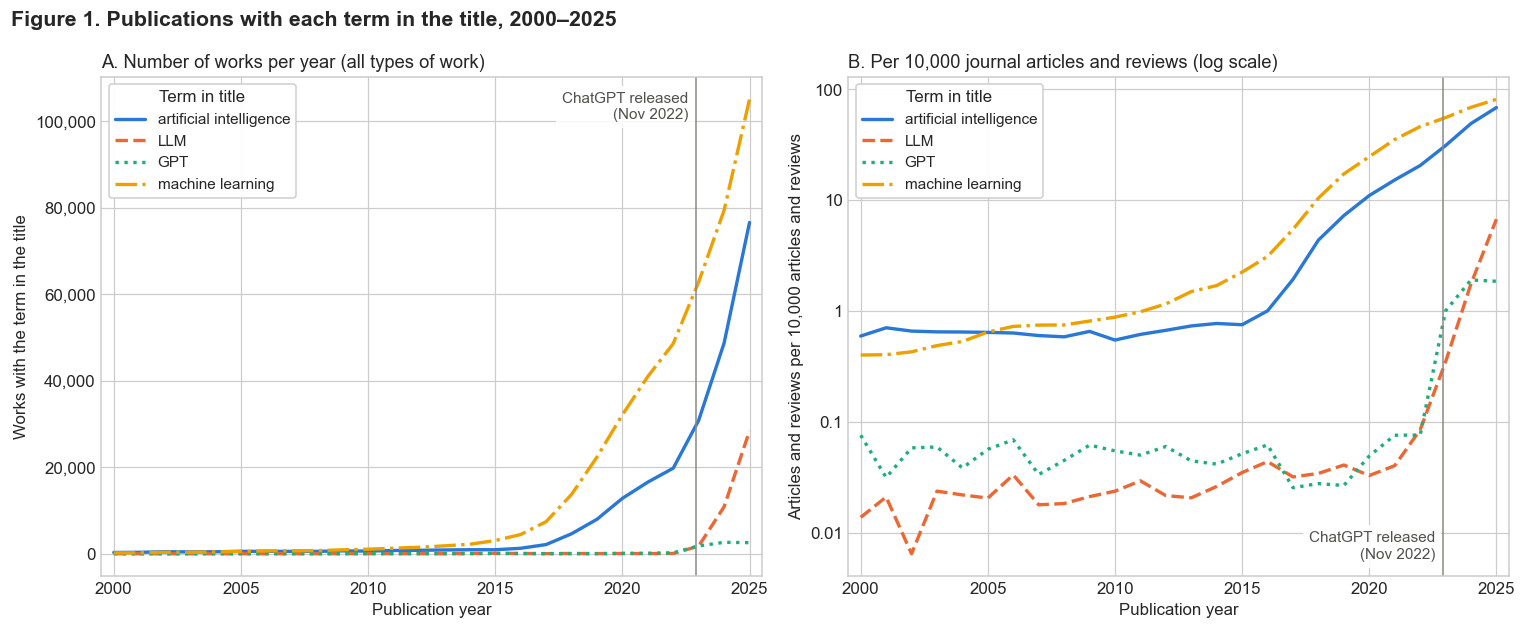

In [19]:
# rate_per_10k: journal articles and reviews with the term in the title, per 10,000
# journal articles and reviews published that year (adjusts for the growth of publishing)
rate_per_10k = yearly_articles.div(totals.loc[2000:2025, "articles"], axis = 0) * 10000

fig, list_axes = plt.subplots(1, 2, figsize = (14, 5.8))

list_panels = [{"data":   yearly_works,
                "title":  "A. Number of works per year (all types of work)",
                "ylabel": "Works with the term in the title",
                "scale":  "linear"},
               {"data":   rate_per_10k,
                "title":  "B. Per 10,000 journal articles and reviews (log scale)",
                "ylabel": "Articles and reviews per 10,000 articles and reviews",
                "scale":  "log"}]

for i in range(2):
    ax    = list_axes[i]
    panel = list_panels[i]
    for keyword in list_keywords:
        values = panel["data"][keyword]
        if panel["scale"] == "log":
            values = values.replace(0, np.nan)         # a log scale cannot show 0
        ax.plot(values.index, values, color = dict_colors[keyword], linestyle = dict_styles[keyword],
                linewidth = 2.2, label = keyword)
    ax.set_yscale(panel["scale"])
    ax.axvline(2022.9, color = "#8a8985", linewidth = 1)
    if panel["scale"] == "log":
        label_y, label_va = 0.03, "bottom"          # log panel: place the label below all four lines
    else:
        label_y, label_va = 0.97, "top"             # linear panel: place the label above all four lines
    ax.text(2022.6, label_y, "ChatGPT released\n(Nov 2022)", transform = ax.get_xaxis_transform(),
            ha = "right", va = label_va, fontsize = 10, color = "#52514e",
            bbox = {"facecolor": "white", "edgecolor": "none", "alpha": 0.85})
    ax.set_title(panel["title"], loc = "left", fontsize = 12)
    ax.set_xlabel("Publication year")
    ax.set_ylabel(panel["ylabel"])
    ax.set_xlim(1999.5, 2025.5)
    ax.set_xticks(range(2000, 2026, 5))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,g}"))
    ax.legend(title = "Term in title", loc = "upper left", frameon = True, framealpha = 0.95)

fig.suptitle("Figure 1. Publications with each term in the title, 2000–2025",
             fontsize = 14, fontweight = "bold", x = 0.01, ha = "left")
fig.tight_layout()
plt.show()

In [20]:
list_show_years = [2000, 2010, 2015, 2020, 2022, 2023, 2024, 2025]    # years shown in Tables 12 and 14

# Table 12: number of works in selected years (rows = terms)
growth = yearly_works.loc[list_show_years].T
growth.columns = [str(year) for year in list_show_years]
growth["Growth 2024 to 2025"] = (yearly_works.loc[2025] / yearly_works.loc[2024] - 1) * 100
growth["Share of 2000–2025 total published in 2023–2025"] = (yearly_works.loc[2023:2025].sum()
                                                             / yearly_works.sum() * 100)
growth = growth.reset_index().rename(columns = {"keyword": "Term in title"})

dict_format = {}
for year in list_show_years:
    dict_format[str(year)] = "{:,.0f}"
dict_format["Growth 2024 to 2025"] = "{:+.0f}%"
dict_format["Share of 2000–2025 total published in 2023–2025"] = "{:.0f}%"

display(style_table(growth, "Table 12. Works with each term in the title, selected years (Figure 1A)",
                    dict_format))

# Table 13: year-to-year change (%) since 2016, plus the compound yearly growth 2000–2015
#           ((count 2015 / count 2000) ** (1/15) - 1)
yoy = yearly_works.pct_change() * 100
yoy_table = yoy.loc[2016:2025].reset_index()
yoy_table["year"] = yoy_table["year"].astype(str)

average_row = {"year": "Compound yearly growth, 2000–2015"}
for keyword in list_keywords:
    average_row[keyword] = ((yearly_works.loc[2015, keyword] / yearly_works.loc[2000, keyword]) ** (1 / 15) - 1) * 100
yoy_table = pd.concat([pd.DataFrame([average_row]), yoy_table])

dict_format_yoy = {}
for keyword in list_keywords:
    dict_format_yoy[keyword] = "{:+.0f}%"

display(style_table(yoy_table.rename(columns = {"year": "Year"}),
                    "Table 13. Year-to-year change in the number of works with each term in the title "
                    "(in 2000–2019, 0 of 25 sampled \"LLM\" and 0 of 25 sampled \"GPT\" titles mentioned a language model; see Table 9)",
                    dict_format_yoy))

# Table 14: adjusted series (Figure 1B) in selected years
rates = rate_per_10k.loc[list_show_years].T
rates.columns = [str(year) for year in list_show_years]
rates = rates.reset_index().rename(columns = {"keyword": "Term in title"})

dict_format_rates = {}
for year in list_show_years:
    dict_format_rates[str(year)] = "{:.2f}"

display(style_table(rates, "Table 14. Journal articles and reviews with each term in the title per 10,000 "
                   "journal articles and reviews, selected years (Figure 1B)",
            dict_format_rates))

Term in title,2000,2010,2015,2020,2022,2023,2024,2025,Growth 2024 to 2025,Share of 2000–2025 total published in 2023–2025
artificial intelligence,303,617,933,"12,805","19,781","30,828","48,684","76,545",+57%,68%
LLM,4,21,117,62,76,"1,772","10,865","28,384",+161%,98%
GPT,31,52,54,80,221,"1,819","2,646","2,573",-3%,86%
machine learning,199,"1,053","3,054","32,102","48,565","62,806","79,372","105,008",+32%,57%


Year,artificial intelligence,LLM,GPT,machine learning
"Compound yearly growth, 2000–2015",+8%,+25%,+4%,+20%
2016,+36%,-44%,-6%,+46%
2017,+68%,-50%,-43%,+66%
2018,+117%,+100%,+10%,+85%
2019,+73%,-42%,+19%,+63%
2020,+61%,+63%,+111%,+44%
2021,+29%,-44%,+60%,+28%
2022,+19%,+117%,+73%,+19%
2023,+56%,+2232%,+723%,+29%
2024,+58%,+513%,+45%,+26%


Term in title,2000,2010,2015,2020,2022,2023,2024,2025
artificial intelligence,0.60,0.55,0.76,11.06,20.61,31.19,49.28,68.62
LLM,0.01,0.02,0.04,0.03,0.09,0.35,1.77,6.77
GPT,0.08,0.06,0.05,0.05,0.08,1.01,1.92,1.87
machine learning,0.40,0.89,2.26,24.77,46.21,55.71,68.97,81.39


- AI title matches were fairly flat relative to publishing in the early years shown: 0.60 per 10,000 articles and reviews in 2000, 0.55 in 2010, and 0.76 in 2015. The later increase was much larger, reaching 68.62 per 10,000 in 2025, so the rise was not just due to a larger yearly publication total (Table 14; Figure 1B).
- The rise in AI counts began well before 2023. The all-record count grew by 36% in 2016, 68% in 2017, 117% in 2018, and 73% in 2019 (Table 13).
- "Machine learning" had the most title matches in 2025, with 105,008 works, followed by "artificial intelligence" with 76,545. Their counts grew by 32% and 57%, respectively, from 2024 to 2025 (Table 12; Figure 1A).
- "LLM" grew from 10,865 works in 2024 to 28,384 in 2025, an increase of 161%. "GPT" fell from 2,646 to 2,573, or about 3%. The much larger "ChatGPT" count of 8,812 in 2025 shows why the narrow "GPT" search is sensitive to wording (Tables 10 and 12).
- In Figure 1B, the LLM and GPT rates stayed near zero before the jump in 2023. From 2022 to 2023, LLM rose from 0.09 to 0.35 per 10,000 articles and reviews, and GPT rose from 0.08 to 1.01. LLM continued upward to 6.77 in 2025, while GPT leveled off at about 1.9 in 2024–2025 (Table 14; Figure 1B).
- Recent years account for much of the total: 98% of the "LLM" matches and 68% of the "artificial intelligence" matches from 2000–2025 were published in 2023–2025. These are changes in matching titles as well as publication activity, rather than a count of every paper about each topic (Tables 10 and 12).

## New insight (Questions 5 and 6): How has AI research shifted across fields?

- I wanted to see how the balance of AI papers across research fields had changed, including whether computer science still had the largest share (Tables 15 and 16).
- I grouped articles and reviews by their main research field for 2000–2015, 2016–2022, and 2023–2025 (Table 15).
- I compared each field's share of the AI papers and its number of AI papers per 1,000 articles and reviews in that field. The second measure accounts for differences in field size. I also compared the combined share of the two largest fields to measure concentration (Tables 15 and 16; Figure 2).

In [21]:
# The three periods compared
dict_periods = {"2000–2015": "2000-2015",
                "2016–2022": "2016-2022",
                "2023–2025": "2023-2025"}

list_fields    = []
list_checks_q5 = []
for period in dict_periods:
    years = dict_periods[period]
    name  = years.replace("-", "_")

    # ai_groups:  AI articles and reviews in the period, per primary research field
    # all_groups: ALL articles and reviews in the period, per field (the denominator)
    ai_groups, n_ai_period = get_groups({"filter":   filter_ai + ",publication_year:" + years + ",type:article|review",
                                         "group_by": "primary_topic.field.id:include_unknown"},
                                        "q5_fields_ai_" + name)
    all_groups, n_all_period = get_groups({"filter":   "publication_year:" + years + ",type:article|review",
                                           "group_by": "primary_topic.field.id:include_unknown"},
                                          "q5_fields_all_" + name)

    merged = pd.merge(all_groups.rename(columns = {"count": "papers_all"}),
                      ai_groups[["key", "count"]].rename(columns = {"count": "papers_ai"}),
                      on  = "key",
                      how = "left")
    merged["papers_ai"] = merged["papers_ai"].fillna(0)      # a field with no AI papers
    merged["period"]    = period
    list_fields.append(merged)

    list_checks_q5.append({"Period":                   period,
                           "AI papers":                n_ai_period,
                           "Sum of AI field groups":   ai_groups["count"].sum(),
                           "AI papers, unknown field": ai_groups.query('key_display_name == "unknown"')["count"].sum(),
                           "All papers":               n_all_period,
                           "Sum of all field groups":  all_groups["count"].sum(),
                           "All papers, unknown field": all_groups.query('key_display_name == "unknown"')["count"].sum(),
                           "Fields":                   len(all_groups.query('key_display_name != "unknown"'))})

# fields: one row per field and period (unknown field removed)
#   papers_ai   = AI articles and reviews in the field
#   papers_all  = all articles and reviews in the field
#   share_ai    = the field's share of all AI papers in the period (%)
#   ai_per_1000 = AI papers per 1,000 papers in the field
fields = pd.concat(list_fields).rename(columns = {"key_display_name": "field"})
fields = fields.query('field != "unknown"').copy()

fields["share_ai"]   = fields["papers_ai"] / fields.groupby("period")["papers_ai"].transform("sum") * 100
fields["ai_per_1000"] = fields["papers_ai"] / fields["papers_all"] * 1000

display(style_table(pd.DataFrame(list_checks_q5), "Quality check 5. Field groups (journal articles and reviews)",
            {"AI papers": "{:,.0f}", "Sum of AI field groups": "{:,.0f}", "AI papers, unknown field": "{:,.0f}",
             "All papers": "{:,.0f}", "Sum of all field groups": "{:,.0f}",
             "All papers, unknown field": "{:,.0f}", "Fields": "{:.0f}"}))

Period,AI papers,Sum of AI field groups,"AI papers, unknown field",All papers,Sum of all field groups,"All papers, unknown field",Fields
2000–2015,"4,946","4,946",0,"74,401,892","74,401,892","925,106",26
2016–2022,"37,393","37,393",0,"43,507,696","43,507,696","254,998",26
2023–2025,"96,998","96,998",0,"19,002,085","19,002,085","182,959",26


In [22]:
# Wide tables: one row per field, one column per period
share_wide = fields.pivot(index = "field", columns = "period", values = "share_ai")
rate_wide  = fields.pivot(index = "field", columns = "period", values = "ai_per_1000")
count_wide = fields.pivot(index = "field", columns = "period", values = "papers_ai")

# The ten fields with the most AI papers in 2023–2025
list_top_fields = share_wide.sort_values("2023–2025", ascending = False).index[0:10]

# field_table: Table 15, one row per field (the ten largest in 2023–2025)
field_table = pd.DataFrame({
    "Field":                       list_top_fields,
    "AI papers 2000–2015":         count_wide.loc[list_top_fields, "2000–2015"].values,
    "Share 2000–2015":             share_wide.loc[list_top_fields, "2000–2015"].values,
    "Share 2016–2022":             share_wide.loc[list_top_fields, "2016–2022"].values,
    "Share 2023–2025":             share_wide.loc[list_top_fields, "2023–2025"].values,
    "Per 1,000 papers 2000–2015": rate_wide.loc[list_top_fields, "2000–2015"].values,
    "Per 1,000 papers 2016–2022": rate_wide.loc[list_top_fields, "2016–2022"].values,
    "Per 1,000 papers 2023–2025": rate_wide.loc[list_top_fields, "2023–2025"].values
})
field_table["Times higher (2023–2025 vs 2000–2015)"] = (field_table["Per 1,000 papers 2023–2025"]
                                                         / field_table["Per 1,000 papers 2000–2015"])

# list_n: number of AI papers (known field) in each period, for the caption and Figure 2
list_n = [f"{fields.query('period == @period')['papers_ai'].sum():,.0f}" for period in dict_periods]

display(style_table(field_table,
            "Table 15. AI papers by research field: share of all AI papers, and AI papers per 1,000 papers "
            "in the field (journal articles and reviews; the 10 fields with the most AI papers in 2023–2025). "
            f"AI papers per period: {list_n[0]} / {list_n[1]} / {list_n[2]}. The 2000–2015 rates have 4 decimals "
            "because they are small.",
            {"AI papers 2000–2015": "{:,.0f}",
             "Share 2000–2015": "{:.1f}%", "Share 2016–2022": "{:.1f}%", "Share 2023–2025": "{:.1f}%",
             "Per 1,000 papers 2000–2015": "{:.4f}", "Per 1,000 papers 2016–2022": "{:.2f}",
             "Per 1,000 papers 2023–2025": "{:.2f}", "Times higher (2023–2025 vs 2000–2015)": "{:,.0f}x"}))

Field,AI papers 2000–2015,Share 2000–2015,Share 2016–2022,Share 2023–2025,"Per 1,000 papers 2000–2015","Per 1,000 papers 2016–2022","Per 1,000 papers 2023–2025",Times higher (2023–2025 vs 2000–2015)
Medicine,322,6.5%,28.8%,28.6%,0.0269,1.36,7.42,276x
Computer Science,"1,803",36.5%,21.0%,21.4%,0.5631,3.83,19.41,34x
Social Sciences,214,4.3%,9.7%,12.1%,0.0226,0.55,4.12,182x
Engineering,"1,190",24.1%,12.6%,8.8%,0.0695,0.63,3.37,48x
"Business, Management and Accounting",207,4.2%,5.5%,6.7%,0.1096,1.58,9.88,90x
"Economics, Econometrics and Finance",66,1.3%,3.5%,3.3%,0.0342,1.13,6.18,181x
Decision Sciences,171,3.5%,2.6%,3.0%,0.3077,2.61,17.02,55x
Environmental Science,205,4.1%,3.1%,2.5%,0.0684,0.60,2.55,37x
Psychology,86,1.7%,1.6%,2.2%,0.0509,0.47,3.55,70x
Health Professions,66,1.3%,1.9%,1.8%,0.0396,0.61,3.46,87x


In [23]:
# Table 16: how concentrated AI papers are across fields in each period
list_concentration = []
for period in dict_periods:
    period_fields = fields[fields["period"] == period].sort_values("share_ai", ascending = False)
    list_concentration.append({
        "Period":                               period,
        "AI papers (known field)":              period_fields["papers_ai"].sum(),
        "Fields with at least one AI paper":    (period_fields["papers_ai"] > 0).sum(),
        "Fields with at least 1% of AI papers": (period_fields["share_ai"] >= 1).sum(),
        "Two largest fields":                   period_fields["field"].iloc[0] + " + " + period_fields["field"].iloc[1],
        "Share of the two largest fields":      period_fields["share_ai"].iloc[0:2].sum(),
        # effective number of fields = 1 / sum of squared shares (equals n if n fields had equal shares)
        "Effective number of fields":           1 / ((period_fields["share_ai"] / 100) ** 2).sum()})

display(style_table(pd.DataFrame(list_concentration),
            f"Table 16. Concentration of AI papers across the {fields['field'].nunique()} research fields",
            {"AI papers (known field)": "{:,.0f}", "Share of the two largest fields": "{:.1f}%",
             "Effective number of fields": "{:.1f}"}))

Period,AI papers (known field),Fields with at least one AI paper,Fields with at least 1% of AI papers,Two largest fields,Share of the two largest fields,Effective number of fields
2000–2015,"4,946",26,16,Computer Science + Engineering,60.5%,4.9
2016–2022,"37,393",26,13,Medicine + Computer Science,49.8%,6.2
2023–2025,"96,998",26,15,Medicine + Computer Science,50.0%,6.3


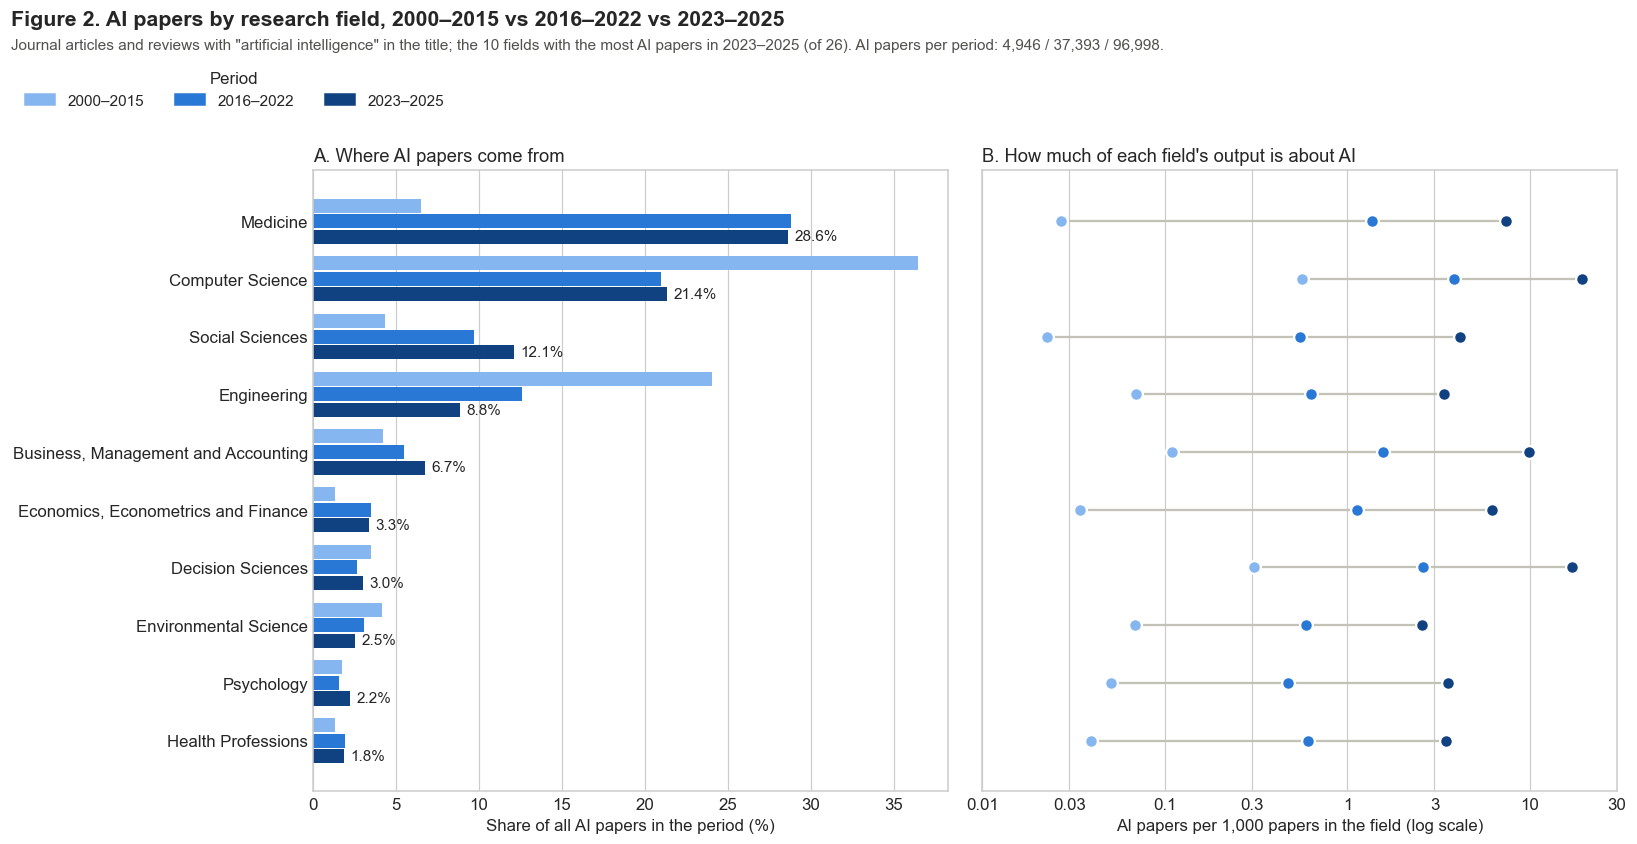

In [24]:
list_plot_fields   = list(list_top_fields)[::-1]           # largest field at the top
list_period_colors = ["#86b6ef", "#2a78d6", "#104281"]     # light = early period, dark = recent
positions          = np.arange(len(list_plot_fields))
bar_height         = 0.27

fig, list_axes = plt.subplots(1, 2, figsize = (15, 7.8), sharey = True)

# Panel A: grouped bars, share of all AI papers in each period
ax    = list_axes[0]
index = 0
for period in dict_periods:
    ax.barh(positions - (index - 1) * bar_height, share_wide.loc[list_plot_fields, period],
            height = bar_height * 0.9, color = list_period_colors[index], label = period)
    index = index + 1
for j in range(len(list_plot_fields)):                     # value labels for the latest period only
    value = share_wide.loc[list_plot_fields[j], "2023–2025"]
    ax.text(value + 0.4, positions[j] - bar_height, f"{value:.1f}%", va = "center", fontsize = 10)
ax.set_title("A. Where AI papers come from", loc = "left", fontsize = 12)
ax.set_xlabel("Share of all AI papers in the period (%)")
ax.set_yticks(positions)
ax.set_yticklabels(list_plot_fields)
ax.grid(axis = "y", visible = False)

# Panel B: dot plot on a log scale (bars are not used because a log axis has no zero)
ax = list_axes[1]
for j in range(len(list_plot_fields)):                     # grey line joining each field's three periods
    ax.plot(rate_wide.loc[list_plot_fields[j], list(dict_periods)], [positions[j]] * 3,
            color = "#c3c2b7", linewidth = 1.5, zorder = 1)
index = 0
for period in dict_periods:
    ax.scatter(rate_wide.loc[list_plot_fields, period], positions, s = 70, color = list_period_colors[index],
               edgecolor = "white", linewidth = 1.5, zorder = 2)
    index = index + 1
ax.set_xscale("log")
ax.set_xticks([0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30])
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,g}"))
ax.xaxis.set_minor_formatter(StrMethodFormatter(""))
ax.set_title("B. How much of each field's output is about AI", loc = "left", fontsize = 12)
ax.set_xlabel("AI papers per 1,000 papers in the field (log scale)")
ax.grid(axis = "y", visible = False)

fig.suptitle("Figure 2. AI papers by research field, 2000–2015 vs 2016–2022 vs 2023–2025",
             fontsize = 14, fontweight = "bold", x = 0.01, ha = "left")
fig.text(0.01, 0.935, 'Journal articles and reviews with "artificial intelligence" in the title; the 10 fields with '
                      f"the most AI papers in 2023–2025 (of {fields['field'].nunique()}). AI papers per period: "
                      f"{list_n[0]} / {list_n[1]} / {list_n[2]}.",
         fontsize = 10, color = "#52514e")
fig.legend(handles = [plt.Rectangle((0, 0), 1, 1, color = color) for color in list_period_colors],
           labels = list(dict_periods), title = "Period", loc = "upper left", ncol = 3,
           bbox_to_anchor = (0.01, 0.925), frameon = False)
fig.tight_layout(rect = (0, 0, 1, 0.885))
plt.show()

- Medicine's share rose from 6.5% in 2000–2015 to 28.8% in 2016–2022, then stayed almost unchanged at 28.6% in 2023–2025. Computer science's share fell from 36.5% to 21.0%, then edged up to 21.4%. The main shift toward medicine had therefore already happened by the middle period (Table 15; Figure 2A).
- Engineering's share kept falling, from 24.1% to 12.6% to 8.8%. Social sciences moved in the other direction, from 4.3% to 9.7% to 12.1% (Table 15).
- All 26 fields had at least one AI paper in every period, so these results do not show AI entering a larger number of fields. What changed was concentration: the two largest fields accounted for 60.5%, 49.8%, and 50.0% of AI papers across the three periods. Most of that reduction had also happened by 2016–2022 (Table 16).
- AI papers became more common within both medicine and computer science. The "Times higher" column shows that the rate per 1,000 papers in 2023–2025 was about 276 times the 2000–2015 rate in medicine and 34 times the earlier rate in computer science (Table 15; Figure 2B).
- Medicine's 276-fold increase starts from a small base: only 322 AI articles and reviews in 2000–2015, or 0.0269 per 1,000 papers in the field. The large ratio needs to be read alongside that starting count and the later rate of 7.42 per 1,000 (Table 15).
- Medicine contributed more AI papers in the latest period, but computer science had a higher rate within its own field: 19.41 per 1,000 papers compared with medicine's 7.42. Computer science's smaller share of all AI papers therefore does not mean AI became less common within computer science (Table 15; Figure 2).

## Limitations

- A title search misses papers that discuss AI without using the chosen words in the title. The phrase and two-word totals are close, but the GPT/ChatGPT comparison shows that other wording choices can change the results substantially (Tables 1 and 10).
- "GPT" and "LLM" can mean other things, especially in the earlier years. The small title samples show this problem but cannot tell us the overall rate of unrelated matches (Table 9).
- Country information was missing for 36.9% of the country-analysis sample. International works also count once for each represented country, so these shares overlap and describe participation rather than separate portions of the world total (Table 4; Quality check 2).
- The partial year 2026 makes up 28.2% of the Q2 sample. The top four ranks stay the same without it, but Nigeria moves from 20th to 26th and Canada from 10th to 8th, so some rankings depend on the cutoff (Table 4; Quality check 2).
- The DOI check confirmed a wrong-title record in OpenAlex. It was excluded from the final top ten because it was a preprint, but it remains in the uncorrected aggregate title-search counts. Checking one record does not establish how common this problem is (Tables 5 and 6).
- Missing years, unusual dates, and repeated author entries show that the metadata need care. The checks identified specific problems and the year filters exclude out-of-range dates, but they do not verify every record (Tables 2 and 8; Quality checks 1 and 3).
- Citation counts change, and older papers have had more time to collect citations. All ten leading papers were dated 2017–2020, so the ranking should not be treated as a direct comparison of paper quality across years (Table 7).
- OpenAlex's all-record total jumps by 34.7% in 2025 and 121.2% in 2026. These differences may reflect changes in database coverage or record types as well as publication activity. Restricting the adjusted rates to articles and reviews reduces that problem but does not remove possible coverage changes (Tables 11 and 14).
- Each paper is assigned one main field here, which can hide work spanning several fields. The field comparisons describe that assignment, and large rate ratios can be driven partly by small starting counts, such as medicine's 322 early AI papers (Tables 15 and 16).
- The findings describe the responses saved on September 28, 2026. The 2026 counts cover only part of the year, and later updates could change both counts and rankings (Tables 2, 4, and A1).

## Appendix: API requests

- Table A1 lists each API request, its saved JSON filename, and the retrieval date, including the DataCite lookup used for the DOI check.

In [25]:
# One row per request (duplicates removed), with the query parameters that matter
list_rows  = []     # one row per request for Table A1
list_dates = []     # retrieval date of each saved response
for request in list_requests:
    with open(folder_cache + request["file"], "r", encoding = "utf-8") as file:
        list_dates.append(json.load(file)["retrieved"])

    grouped_or_sorted = request["parameters"].get("group_by", request["parameters"].get("sort", ""))
    list_rows.append({"API":                   "OpenAlex" if request["url"] == url_openalex_works else "DataCite",
                      "Saved as":              request["file"],
                      "Filter":                request["parameters"].get("filter", request["url"].replace(url_datacite, "")),
                      "Grouped by / sorted by": grouped_or_sorted})

requests_table = pd.DataFrame(list_rows).drop_duplicates(subset = "Saved as")
display(style_table(requests_table,
            f"Table A1. The {len(requests_table)} API requests used in this report "
            f"(retrieved {', '.join(sorted(set(list_dates)))})",
            {}))

API,Saved as,Filter,Grouped by / sorted by
OpenAlex,q1_title_phrase.json,"title.search:""artificial intelligence""",
OpenAlex,q1_title_words.json,title.search:artificial intelligence,
OpenAlex,q1_by_year.json,"title.search:""artificial intelligence""",publication_year:include_unknown
OpenAlex,q1_by_type.json,"title.search:""artificial intelligence""",type
OpenAlex,q2_countries_page1.json,"title.search:""artificial intelligence"",publication_year:2000-2026",authorships.countries:include_unknown
OpenAlex,q2_countries_page2.json,"title.search:""artificial intelligence"",publication_year:2000-2026",authorships.countries:include_unknown
OpenAlex,q2_countries_2000_2025_page1.json,"title.search:""artificial intelligence"",publication_year:2000-2025",authorships.countries:include_unknown
OpenAlex,q2_countries_2000_2025_page2.json,"title.search:""artificial intelligence"",publication_year:2000-2025",authorships.countries:include_unknown
OpenAlex,q3_top_cited_any_type.json,"title.search:""artificial intelligence"",publication_year:2000-2026",cited_by_count:desc
DataCite,q3_datacite_W4221143046.json,10.48550/arxiv.2201.11903,
